# Richness projection without completeness correction

This notebook compares the conditional richness distributions with projection OFF and ON at M200c = 3e14 Msun/h and z = 0.5. It then uses the same recipe to predict counts in the original 4-by-4 observed-richness and redshift bins. Completeness and purity corrections are both disabled.

The cosmology and intrinsic Murata parameters match cluster_recipe.ipynb. The survey area is 400 deg2. We use tau(rich_tru) = tau_ref * 20 / rich_tru, initially with tau_ref = 0.20. Thus tau(rich_tru) = 4 / rich_tru. The Costanzi+19 projection parameters are illustrative, not fitted to a particular sample.

The halo mass definition is 200c. Recipe masses are in Msun; the fixed mass given in Msun/h is explicitly converted below. The finite true-richness grid is not renormalized and requires convergence checks over the parameter prior. With these illustrative parameters, low-mass halos can scatter into the observed bins, so the counts depend strongly on the projection calibration and lower mass limit.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyccl as ccl
from scipy.integrate import simpson

from crow import ClusterAbundance, kernel, mass_proxy
from crow.cluster_modules.projection_effects import CostanziRichnessBias
from crow.recipes.binned_grid import GridBinnedClusterRecipe

# Same cosmology and intrinsic Murata parameters as cluster_recipe.ipynb.
cosmo = ccl.Cosmology(
    Omega_c=0.2607, Omega_b=0.04897, h=0.6766,
    sigma8=0.8102, n_s=0.9665,
)
hmf = ccl.halos.MassFuncTinker08(mass_def="200c")
cluster_theory = ClusterAbundance(cosmo, hmf)
redshift_distribution = kernel.SpectroscopicRedshift()
pivot_mass, pivot_redshift = 14.625862906, 0.6
richness_parameters = {
    "mu0": 3.0, "mu1": 0.8, "mu2": -0.3,
    "sigma0": 0.3, "sigma1": 0.0, "sigma2": 0.0,
}

sky_area = 400.0  # 400 deg2
mass_interval = (12.5, 17.0)  # log10(M / Msun)
mass_grid_size, redshift_grid_size, proxy_grid_size = 60, 20, 20
z_edges = np.linspace(0.2, 0.8, 5)
log_proxy_edges = np.linspace(1.0, 1.6, 5)  # log10(rich_obs)
z_bins = list(zip(z_edges[:-1], z_edges[1:]))
proxy_bins = list(zip(log_proxy_edges[:-1], log_proxy_edges[1:]))
richness_centers = 10.0 ** (0.5 * (log_proxy_edges[:-1] + log_proxy_edges[1:]))

# Integration coordinates, in natural log true richness.
ln_rich_tru = np.linspace(np.log(0.01), np.log(10000.0), 801)
# Build tau on this grid, in inverse linear richness.
tau_ref, rich_ref = 0.20, 20.0
tau = tau_ref * rich_ref / np.exp(ln_rich_tru)
# For constant tau, use tau = tau_ref instead.
# Illustrative Costanzi+19 projection parameters.
projection_parameters = {
    "tau": tau,
    "delta_mu": -2.0,
    "fractional_sig_pure": 0.15,
    "fprj": 0.95,
    "fmsk": 0.05,
}

recipe = GridBinnedClusterRecipe(
    cluster_theory=cluster_theory,
    redshift_distribution=redshift_distribution,
    mass_distribution=mass_proxy.MurataUnbinned(pivot_mass, pivot_redshift),
    completeness=None,
    purity=None,
    mass_interval=mass_interval,
    mass_grid_size=mass_grid_size,
    redshift_grid_size=redshift_grid_size,
    proxy_grid_size=proxy_grid_size,
    projection_model=CostanziRichnessBias(**projection_parameters),
    ln_rich_tru=ln_rich_tru,
)
recipe.mass_distribution.parameters.update(richness_parameters)


## Compare richness distributions at fixed mass and redshift

Use M200c = 3e14 Msun/h and z = 0.5. The recipe expects log10 mass in Msun, so divide the supplied mass by h before taking log10.

With projection OFF, the Murata distribution describes rich_obs. When projection is ON, this same intrinsic distribution instead describes rich_tru. The projection kernel then maps rich_tru to rich_obs:

`P_on(rich_obs | M, z) = integral dln(rich_tru) P(rich_obs | rich_tru, projection_params) P(ln(rich_tru) | M, z, richness_parameters)`

The two curves below are densities per unit linear rich_obs. Murata returns a density per ln richness, so the OFF curve is divided by rich_obs. The projection kernel already returns a density per linear rich_obs, so its integral needs no additional observed-richness factor.

This calculation uses the models and true-richness grid stored on the recipe, at the exact chosen mass and redshift. It integrates only over true richness, not halo mass or redshift. No normalization over the plotted positive-richness range is imposed.

Before creating the recipe, we build the tau array as tau_ref * rich_ref / np.exp(ln_rich_tru). CostanziRichnessBias receives these rates directly; it accepts either a scalar for constant tau or an array matching the true-richness coordinates. Rebuild the array if those coordinates change. At rich_tru = rich_ref, tau equals tau_ref, and the positive exponential scale 1 / tau is proportional to rich_tru. This is a trial calibration law, not a fitted Costanzi+19 relation.


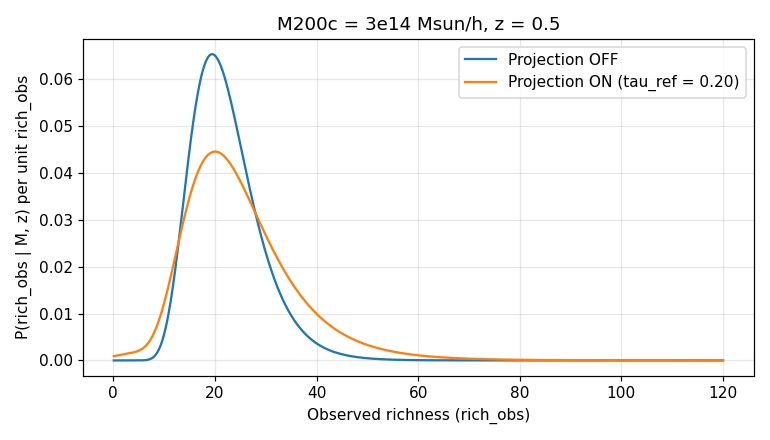

In [2]:
# Convert the supplied M200c from Msun/h to Msun.
mass_cluster_msun_over_h = 3e14
mass_cluster_msun = mass_cluster_msun_over_h / cosmo["h"]
log_mass_cluster = np.log10(mass_cluster_msun)
z_cluster = 0.5
rich_obs = np.linspace(0.1, 120.0, 1500)

# Projection OFF: intrinsic density per ln richness, then per linear richness.
p_ln_rich_obs = recipe.mass_distribution.distribution(
    np.full_like(rich_obs, log_mass_cluster),
    np.full_like(rich_obs, z_cluster),
    np.log10(rich_obs),
)
p_rich_obs_off = p_ln_rich_obs / rich_obs

# Projection ON: the intrinsic relation now describes rich_tru.
rich_tru = np.exp(recipe.ln_rich_tru)
p_ln_rich_tru = recipe.mass_distribution.distribution(
    np.full_like(rich_tru, log_mass_cluster),
    np.full_like(rich_tru, z_cluster),
    recipe.ln_rich_tru / np.log(10.0),
)
projection_kernel = recipe.projection_model.prob_richobs_at_richtru(
    rich_obs=rich_obs,
    rich_tru=rich_tru,
)
p_rich_obs_on = simpson(
    y=projection_kernel * p_ln_rich_tru[None, :],
    x=recipe.ln_rich_tru,
    axis=1,
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(rich_obs, p_rich_obs_off, label="Projection OFF")
ax.plot(
    rich_obs, p_rich_obs_on,
    label=f"Projection ON (tau_ref = {tau_ref:.2f})",
)
ax.set_xlabel("Observed richness (rich_obs)")
ax.set_ylabel("P(rich_obs | M, z) per unit rich_obs")
ax.set_title("M200c = 3e14 Msun/h, z = 0.5")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## Predict counts with the same recipe

The counts calculation additionally integrates over halo mass, redshift, and each observed-richness bin. Only the projection switch changes between the OFF and ON calls. OFF is the default. Completeness and purity corrections remain disabled.

Rows in each count matrix are redshift bins; columns are observed-richness bins.


Rows = redshift bins; columns = observed-richness bins
Projection OFF:
 [[207.144  99.147  42.769  16.177]
 [316.65  142.224  56.764  19.54 ]
 [351.519 146.68   53.545  16.557]
 [321.288 123.372  40.753  11.186]]
Projection ON (tau_ref = 0.20):
 [[197.632 111.689  56.747  25.557]
 [307.498 165.506  79.231  33.217]
 [349.083 177.668  79.49   30.746]
 [328.024 156.838  65.108  23.055]]


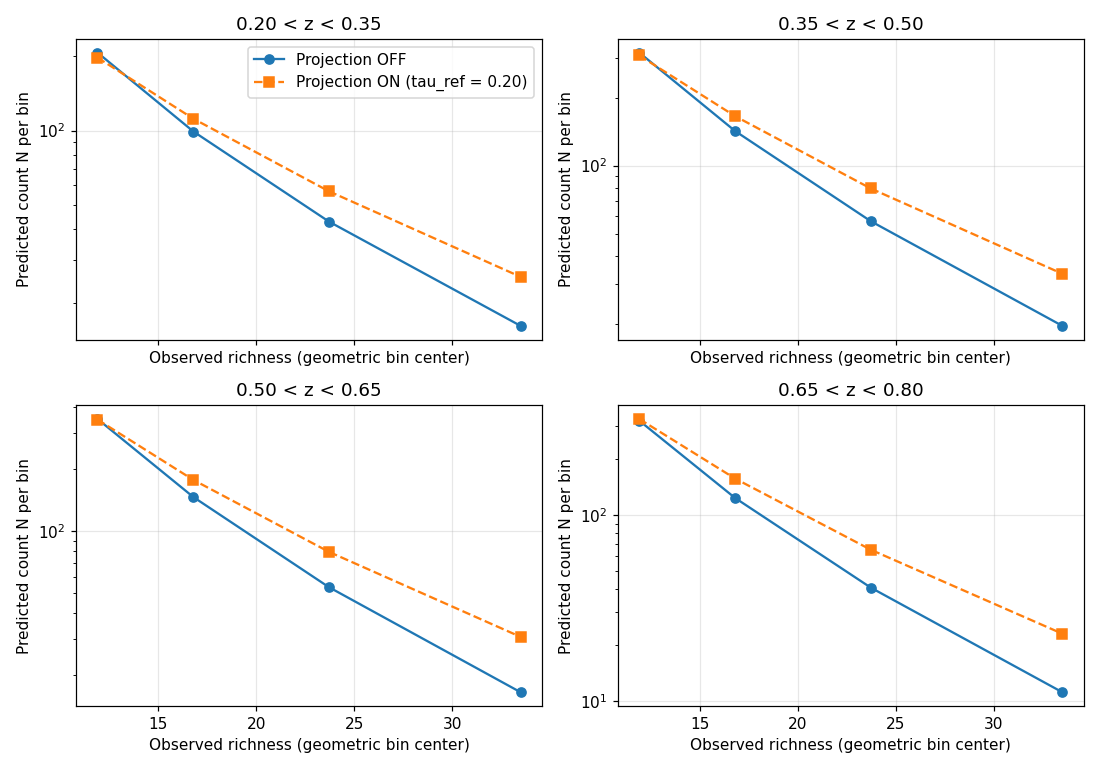

In [3]:
recipe.setup()  # Once per parameter set, before looping over bins.
counts_off = np.zeros((4, 4))
counts_on = np.zeros((4, 4))
for i, z_bin in enumerate(z_bins):
    for j, proxy_bin in enumerate(proxy_bins):
        counts_off[i, j] = recipe.evaluate_theory_prediction_counts(
            z_bin, proxy_bin, sky_area, projection=False
        )
        counts_on[i, j] = recipe.evaluate_theory_prediction_counts(
            z_bin, proxy_bin, sky_area, projection=True
        )

assert np.all(np.isfinite(counts_off)) and np.all(counts_off > 0)
assert np.all(np.isfinite(counts_on)) and np.all(counts_on > 0)
print("Rows = redshift bins; columns = observed-richness bins")
print("Projection OFF:\n", np.array2string(counts_off, precision=3))
print(
    f"Projection ON (tau_ref = {tau_ref:.2f}):\n",
    np.array2string(counts_on, precision=3),
)

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)
for i, ax in enumerate(axes.flat):
    ax.plot(richness_centers, counts_off[i], "o-", label="Projection OFF")
    ax.plot(
        richness_centers, counts_on[i], "s--",
        label=f"Projection ON (tau_ref = {tau_ref:.2f})",
    )
    ax.set_title(f"{z_bins[i][0]:.2f} < z < {z_bins[i][1]:.2f}")
    ax.set_xlabel("Observed richness (geometric bin center)")
    ax.set_ylabel("Predicted count N per bin")
    ax.set_yscale("log")
    ax.grid(alpha=0.3)
axes[0, 0].legend()
fig.tight_layout()
plt.show()


## Update a projection parameter and recalculate

Change only the reference rate tau_ref from 0.20 to 0.40, keeping the inverse-richness scaling and reference richness of 20 fixed. Rebuild the tau array using the stored recipe.ln_rich_tru grid, update recipe.projection_model.parameters["tau"], and call recipe.setup() to clear caches before recalculating. The stored parameter is the array of rates, not tau_ref; the projection model does not infer a richness dependence. The OFF counts should remain unchanged.

In a sampler, update all sampled model parameters first and call recipe.setup() once before evaluating the bins.


In [4]:
updated_tau_ref = 0.40
tau_updated = updated_tau_ref * rich_ref / np.exp(recipe.ln_rich_tru)
recipe.projection_model.parameters.update({"tau": tau_updated})
recipe.setup()

counts_on_updated = np.zeros((4, 4))
counts_off_updated = np.zeros((4, 4))
for i, z_bin in enumerate(z_bins):
    for j, proxy_bin in enumerate(proxy_bins):
        counts_on_updated[i, j] = recipe.evaluate_theory_prediction_counts(
            z_bin, proxy_bin, sky_area, projection=True
        )
        counts_off_updated[i, j] = recipe.evaluate_theory_prediction_counts(
            z_bin, proxy_bin, sky_area, projection=False
        )

np.testing.assert_allclose(counts_off_updated, counts_off)
assert np.all(np.isfinite(counts_on_updated)) and np.all(counts_on_updated > 0)
assert not np.allclose(counts_on_updated, counts_on)
print("Projection ON with tau_ref = 0.40:")
print(np.array2string(counts_on_updated, precision=3))
print("Projection OFF counts are unchanged.")


Projection ON with tau_ref = 0.40:
[[159.206  87.513  42.85   18.37 ]
 [242.719 126.454  57.97   22.942]
 [268.908 131.719  56.01   20.249]
 [245.566 112.247  43.9    14.363]]
Projection OFF counts are unchanged.
